# Accent Coach — Phase 0 Validation

Three comparisons, all using the same 50 calibration sentences:

| | Speaker | Reference | Target |
|---|---|---|---|
| **A** | IndexTTS BC synth | RP norms | ≥ 85 |
| **B** | You | RP norms | ≤ 65 |
| **C** | You | IndexTTS BC synth | within ±5 of B |

BC audio = `tts_output/accent_coach/bc_cal_50/indextts_cal_NNN.wav`  
Your audio = `tts_output/accent_coach/users/owner/NNN_*.wav`

Re-run as more BC files finish generating — cells skip sentences whose WAV doesn't exist yet.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130

from accent_coach.calibration.sentences import CALIBRATION_SENTENCES, get_by_id
from accent_coach.pipeline.features import analyse_audio
from accent_coach.comparison.scoring import compare
from accent_coach.reference.rp_norms import get_rp_norms, RP_VOWEL_F1_F2_MALE

BC_DIR   = Path("../tts_output/accent_coach/bc_cal_50")
USER_DIR = Path("../tts_output/accent_coach/users/owner")

def bc_wav(sid: int) -> Path:
    return BC_DIR / f"indextts_cal_{sid:03d}.wav"

def user_wav(sid: int) -> Path | None:
    matches = sorted(USER_DIR.glob(f"{sid:03d}_*.wav"))
    return matches[0] if matches else None

bc_done   = sum(1 for s in CALIBRATION_SENTENCES if bc_wav(s.id).exists())
user_done = sum(1 for s in CALIBRATION_SENTENCES if user_wav(s.id) is not None)
print(f"BC synth ready : {bc_done} / 50")
print(f"Your recordings: {user_done} / 50")

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.

BC synth ready : 50 / 50
Your recordings: 50 / 50


In [2]:
def analyse(wav: Path, sentence_id: int):
    """Return (SentenceAnalysis, audio_array, sr) for a WAV."""
    meta = get_by_id(sentence_id)
    analysis = analyse_audio(wav, meta.text, meta)
    audio, sr = sf.read(str(wav), always_2d=False)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    return analysis, audio.astype("float32"), sr

def score_vs_rp(analysis, audio, sr):
    """Score a SentenceAnalysis against RP norms."""
    mean_f0 = float(np.mean([v.pitch_mean for v in analysis.vowels if v.pitch_mean > 70] or [120.0]))
    rp = get_rp_norms(mean_f0)
    return compare(analysis, audio, sr, reference_norms=rp)

def score_vs_target(analysis, audio, sr, target_analysis):
    """Score a SentenceAnalysis against another SentenceAnalysis (BC synth)."""
    mean_f0 = float(np.mean([v.pitch_mean for v in analysis.vowels if v.pitch_mean > 70] or [120.0]))
    rp = get_rp_norms(mean_f0)
    return compare(analysis, audio, sr, target=target_analysis, reference_norms=rp)

def result_row(result, sid, label):
    return {
        "sid": sid, "label": label,
        "composite": result.composite_score,
        **result.skill_scores,
        "npvi": result.rhythm_breakdown.npvi,
        "diagnostics": result.vowel_diagnostics,
        "vowels_raw": None,  # filled per experiment
    }

In [3]:
# ── Experiment A: IndexTTS BC vs RP ───────────────────────────────
exp_a = []
bc_vowels_all = []

for s in CALIBRATION_SENTENCES:
    wav = bc_wav(s.id)
    if not wav.exists():
        continue
    analysis, audio, sr = analyse(wav, s.id)
    result = score_vs_rp(analysis, audio, sr)
    row = result_row(result, s.id, s.text[:40])
    row["vowels_raw"] = analysis.vowels
    exp_a.append(row)
    bc_vowels_all.extend(analysis.vowels)

if exp_a:
    mean_a = np.mean([r["composite"] for r in exp_a])
    print(f"Exp A  ({len(exp_a)}/50 sentences)  composite = {mean_a:.1f}  (target ≥ 85)")
else:
    print("Exp A: no BC synth files yet — still generating")

Exp A  (50/50 sentences)  composite = 45.2  (target ≥ 85)


In [4]:
# ── Experiment B: You vs RP ────────────────────────────────────────
exp_b = []
user_vowels_all = []

for s in CALIBRATION_SENTENCES:
    wav = user_wav(s.id)
    if wav is None:
        continue
    analysis, audio, sr = analyse(wav, s.id)
    result = score_vs_rp(analysis, audio, sr)
    row = result_row(result, s.id, s.text[:40])
    row["vowels_raw"] = analysis.vowels
    exp_b.append(row)
    user_vowels_all.extend(analysis.vowels)

if exp_b:
    mean_b = np.mean([r["composite"] for r in exp_b])
    print(f"Exp B  ({len(exp_b)}/50 sentences)  composite = {mean_b:.1f}  (target ≤ 65)")
else:
    print("Exp B: no user recordings found")

Exp B  (50/50 sentences)  composite = 46.6  (target ≤ 65)


In [5]:
# ── Experiment C: You vs IndexTTS BC (paired) ─────────────────────
exp_c = []

bc_cache: dict[int, tuple] = {}   # sid → (analysis, audio, sr)

for s in CALIBRATION_SENTENCES:
    u_wav = user_wav(s.id)
    b_wav = bc_wav(s.id)
    if u_wav is None or not b_wav.exists():
        continue

    u_analysis, u_audio, u_sr = analyse(u_wav, s.id)

    if s.id not in bc_cache:
        bc_cache[s.id] = analyse(b_wav, s.id)
    b_analysis, _, _ = bc_cache[s.id]

    result = score_vs_target(u_analysis, u_audio, u_sr, b_analysis)
    row = result_row(result, s.id, s.text[:40])
    exp_c.append(row)

if exp_c:
    mean_c = np.mean([r["composite"] for r in exp_c])
    print(f"Exp C  ({len(exp_c)}/50 paired)  composite = {mean_c:.1f}")
    if exp_b:
        mean_b_paired = np.mean([r["composite"] for r in exp_b if r["sid"] in {r2["sid"] for r2 in exp_c}])
        print(f"  Exp B (same sentences) = {mean_b_paired:.1f}  →  diff = {mean_c - mean_b_paired:+.1f}  (target within ±5)")
else:
    print("Exp C: needs both BC synth and user recordings for the same sentences")

Exp C  (50/50 paired)  composite = 63.4
  Exp B (same sentences) = 46.6  →  diff = +16.8  (target within ±5)


In [6]:
# ── Score summary table ───────────────────────────────────────────
import pandas as pd

skills = ["vowels", "consonants", "aspiration", "rhythm", "stress", "intonation"]
rows = []
for label, results, target in [
    ("A: BC synth vs RP",  exp_a, "≥ 85"),
    ("B: You vs RP",       exp_b, "≤ 65"),
    ("C: You vs BC synth", exp_c, "≈ B ± 5"),
]:
    if not results:
        continue
    row = {
        "Experiment": f"{label}  [{target}]",
        "n": len(results),
        "Composite": np.mean([r["composite"] for r in results]),
    }
    for sk in skills:
        row[sk.capitalize()] = np.mean([r.get(sk, 0) for r in results])
    row["nPVI"] = np.mean([r["npvi"] for r in results])
    rows.append(row)

df = pd.DataFrame(rows).set_index("Experiment")
df.style.format("{:.1f}", subset=[c for c in df.columns if c != "n"]) \
        .format("{:.0f}", subset=["n"]) \
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=100,
                             subset=["Composite"] + [s.capitalize() for s in skills])

,n,Composite,Vowels,Consonants,Aspiration,Rhythm,Stress,Intonation,nPVI
Experiment,,,,,,,,,
A: BC synth vs RP [≥ 85],50,45.2,46.5,70.0,36.4,28.8,8.0,80.7,37.4
B: You vs RP [≤ 65],50,46.6,49.3,70.0,28.6,33.7,12.5,83.4,41.2
C: You vs BC synth [≈ B ± 5],50,63.4,47.8,70.0,43.5,65.4,71.5,92.3,41.2


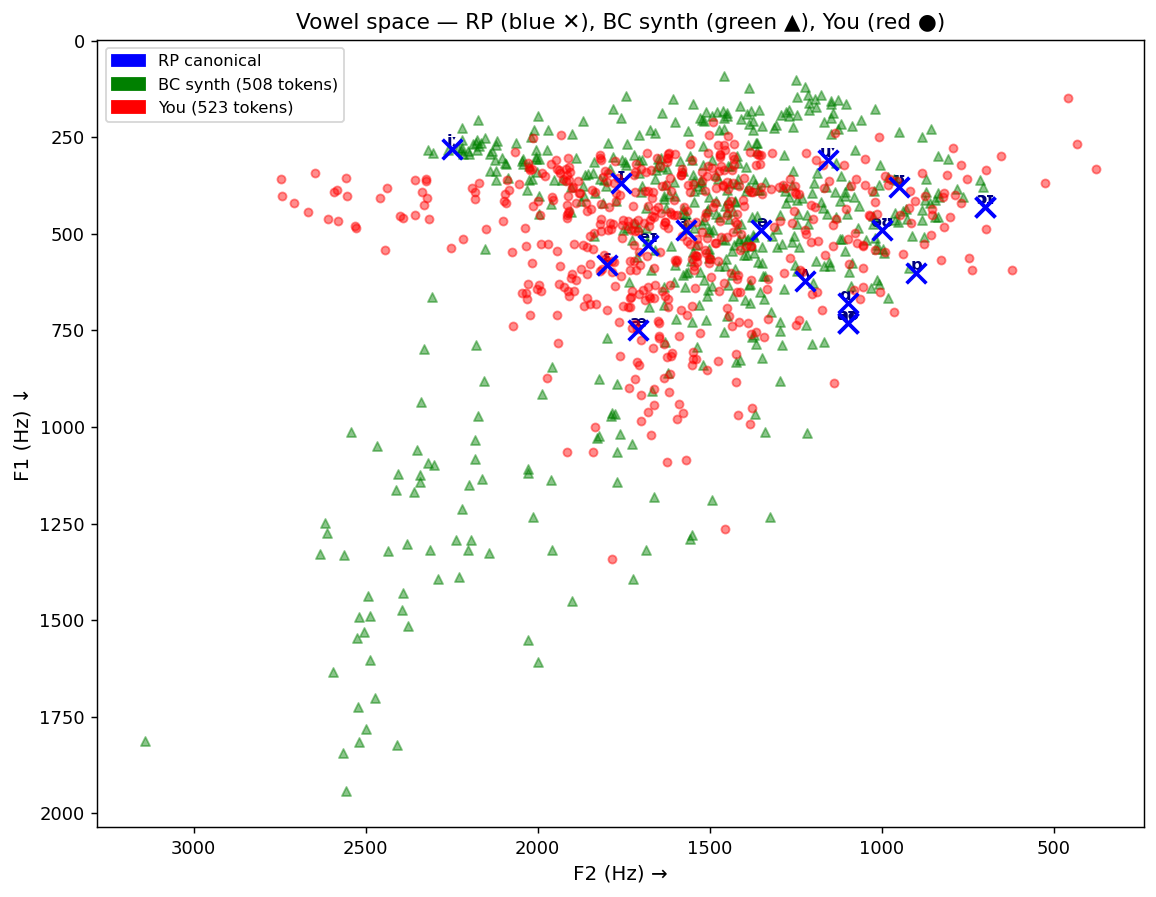

In [7]:
# ── Three-way vowel scatter: RP vs BC synth vs You ────────────────
mean_f0_user = float(np.mean([v.pitch_mean for v in user_vowels_all if v.pitch_mean > 70] or [120.0]))
rp_norms = get_rp_norms(mean_f0_user)

fig, ax = plt.subplots(figsize=(9, 7))

# RP reference centroids
for ph, (f1, f2) in rp_norms.items():
    ax.scatter(f2, f1, marker="x", s=120, color="blue", zorder=5, linewidths=2)
    ax.annotate(ph, (f2, f1), fontsize=9, color="navy",
                ha="center", va="bottom", fontweight="bold")

# BC synth vowels
if bc_vowels_all:
    ax.scatter([v.f2 for v in bc_vowels_all], [v.f1 for v in bc_vowels_all],
               marker="^", s=25, alpha=0.45, color="green", zorder=3)

# User vowels
if user_vowels_all:
    ax.scatter([v.f2 for v in user_vowels_all], [v.f1 for v in user_vowels_all],
               marker="o", s=20, alpha=0.45, color="red", zorder=4)

ax.set_xlabel("F2 (Hz) →", fontsize=11)
ax.set_ylabel("F1 (Hz) ↓", fontsize=11)
ax.invert_yaxis()
ax.invert_xaxis()
ax.set_title("Vowel space — RP (blue ✕), BC synth (green ▲), You (red ●)", fontsize=12)

legend = [
    mpatches.Patch(color="blue",  label="RP canonical"),
    mpatches.Patch(color="green", label=f"BC synth ({len(bc_vowels_all)} tokens)"),
    mpatches.Patch(color="red",   label=f"You ({len(user_vowels_all)} tokens)"),
]
ax.legend(handles=legend, fontsize=9)
plt.tight_layout()
plt.show()

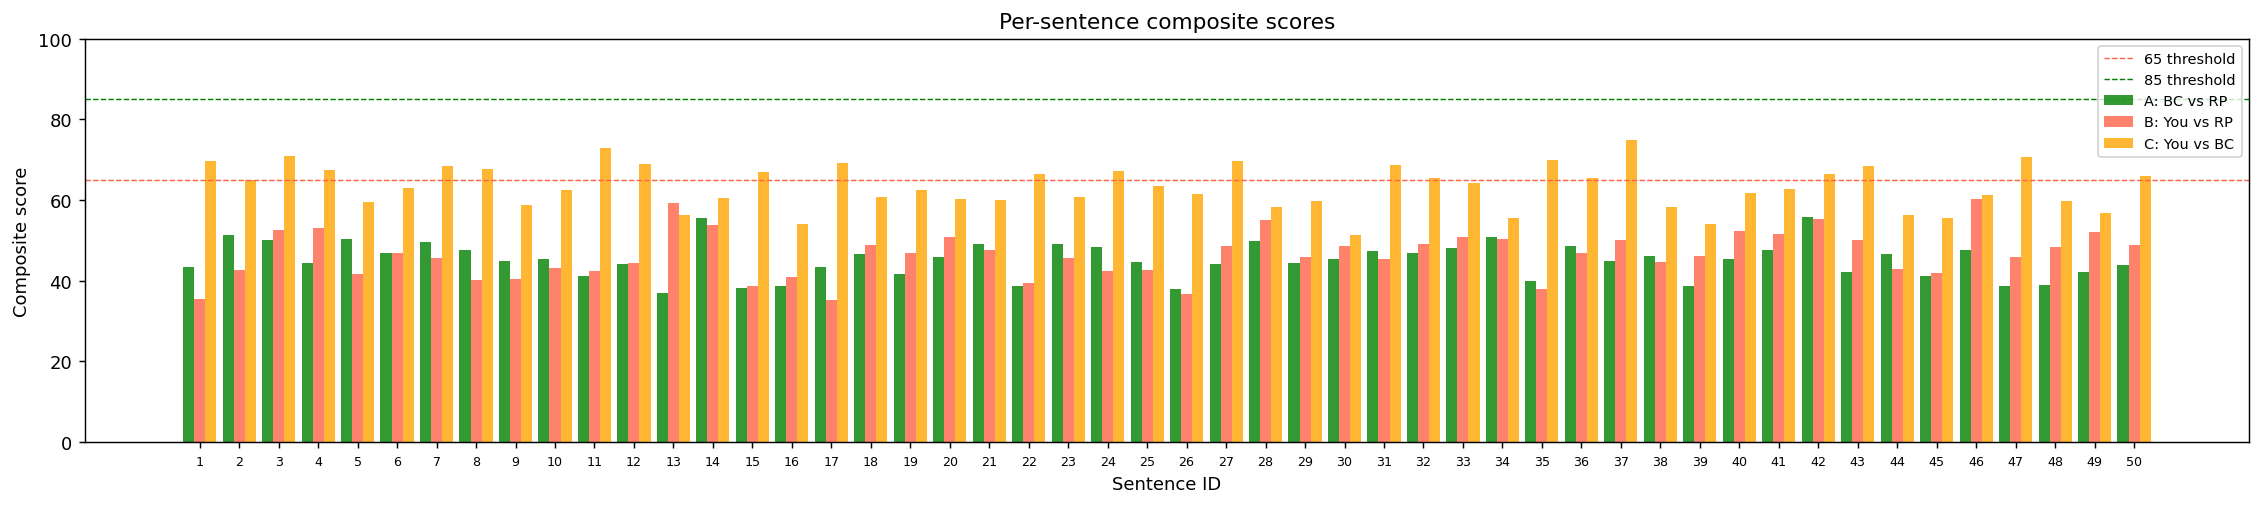

In [8]:
# ── Per-sentence bar chart (composite scores) ─────────────────────
if exp_a or exp_b:
    all_sids = sorted({r["sid"] for r in exp_a + exp_b + exp_c})
    a_map = {r["sid"]: r["composite"] for r in exp_a}
    b_map = {r["sid"]: r["composite"] for r in exp_b}
    c_map = {r["sid"]: r["composite"] for r in exp_c}

    x = np.arange(len(all_sids))
    w = 0.28
    fig, ax = plt.subplots(figsize=(max(12, len(all_sids) * 0.35), 4))
    if a_map:
        ax.bar(x - w, [a_map.get(s, 0) for s in all_sids], w, label="A: BC vs RP",  color="green",  alpha=0.8)
    if b_map:
        ax.bar(x,     [b_map.get(s, 0) for s in all_sids], w, label="B: You vs RP", color="tomato", alpha=0.8)
    if c_map:
        ax.bar(x + w, [c_map.get(s, 0) for s in all_sids], w, label="C: You vs BC", color="orange", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(all_sids, fontsize=7)
    ax.set_xlabel("Sentence ID")
    ax.set_ylabel("Composite score")
    ax.set_ylim(0, 100)
    ax.axhline(65, color="tomato", linestyle="--", linewidth=0.8, label="65 threshold")
    ax.axhline(85, color="green",  linestyle="--", linewidth=0.8, label="85 threshold")
    ax.legend(fontsize=8)
    ax.set_title("Per-sentence composite scores")
    plt.tight_layout()
    plt.show()

In [9]:
# ── Articulatory diagnostics: You vs RP ───────────────────────────
# Aggregate per phoneme across all sentences
from collections import defaultdict

ph_f1_diff: dict[str, list[float]] = defaultdict(list)
ph_f2_diff: dict[str, list[float]] = defaultdict(list)

for row in exp_b:
    for d in row["diagnostics"]:
        ph_f1_diff[d.phoneme].append(d.user_f1 - d.target_f1)
        ph_f2_diff[d.phoneme].append(d.user_f2 - d.target_f2)

print("Your vowel deviations from RP (mean across all sentences)\n")
print(f"{'Phoneme':>8}  {'ΔF1 (Hz)':>10}  {'ΔF2 (Hz)':>10}  Advice")
print("-" * 70)
for ph in sorted(ph_f1_diff, key=lambda p: abs(np.mean(ph_f1_diff[p])) + abs(np.mean(ph_f2_diff[p])), reverse=True):
    df1 = np.mean(ph_f1_diff[ph])
    df2 = np.mean(ph_f2_diff[ph])
    parts = []
    if df1 >  50: parts.append("tongue too low")
    if df1 < -50: parts.append("tongue too high")
    if df2 >  100: parts.append("too far forward")
    if df2 < -100: parts.append("too far back")
    advice = "; ".join(parts) if parts else "on target"
    print(f"  /{ph:>5}/  {df1:>+8.0f}   {df2:>+8.0f}   {advice}")

Your vowel deviations from RP (mean across all sentences)

 Phoneme    ΔF1 (Hz)    ΔF2 (Hz)  Advice
----------------------------------------------------------------------
  /   ɔɪ/       +69       +926   tongue too low; too far forward
  /   ɔː/      +167       +594   tongue too low; too far forward
  /   aɪ/      -102       +639   tongue too high; too far forward
  /   iː/      +257       -470   tongue too low; too far back
  /    ʊ/      +117       +488   tongue too low; too far forward
  /   ɑː/      -129       +349   tongue too high; too far forward
  /   uː/      +111       +366   tongue too low; too far forward
  /    ʌ/      -157       +312   tongue too high; too far forward
  /   aʊ/      -181       +196   tongue too high; too far forward
  /   əʊ/       +31       +227   too far forward
  /    æ/      -186        -34   tongue too high
  /    ɪ/       +89       +123   tongue too low; too far forward
  /   eɪ/       +22       +142   too far forward
  /    ɛ/       -27       -121 